# 用户行为数据分析

本 Notebook 用于分析用户行为数据集，包含用户画像、行为概览、转化漏斗、留存和商品分析。

In [1]:
from pathlib import Path


import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


# 数据集路径。
DATA_DIR = Path('D:/项目/用户行为')

# 表名与文件名的映射，后续可以统一循环读取。
DATA_FILES = {
    'users': 'users.csv',
    'sessions': 'sessions.csv',
    'interactions': 'interactions.csv',
    'products': 'products.csv',
    'purchases': 'purchases.csv',
    'reviews': 'reviews.csv',
}


# 设置中文字体，避免图表中中文显示为方框。
sns.set_theme(style='whitegrid', font='Microsoft YaHei')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False


def load_user_behavior_data(data_dir=DATA_DIR):
    """批量读取用户行为数据，返回表名到 DataFrame 的字典。"""
    data = {}

    for table_name, file_name in DATA_FILES.items():
        file_path = data_dir / file_name
        if not file_path.exists():
            raise FileNotFoundError(f'未找到数据集文件: {file_path}')
        data[table_name] = pd.read_csv(file_path)

    return data


def clean_user_behavior_data(data):
    """清洗数据：转换日期、删除重复主键、过滤明显异常值。"""
    date_columns = {
        'users': ['signup_date'],
        'sessions': ['start_time'],
        'interactions': ['timestamp'],
        'products': ['date_added'],
        'purchases': ['order_date'],
        'reviews': ['review_date'],
    }

    for table_name, columns in date_columns.items():
        for column in columns:
            data[table_name][column] = pd.to_datetime(
                data[table_name][column],
                errors='coerce',
            )

    data['sessions']['is_converted'] = data['sessions']['is_converted'].astype(bool)

    primary_keys = {
        'users': 'user_id',
        'sessions': 'session_id',
        'interactions': 'interaction_id',
        'products': 'product_id',
        'purchases': 'purchase_id',
        'reviews': 'review_id',
    }

    for table_name, primary_key in primary_keys.items():
        data[table_name] = data[table_name].drop_duplicates(
            subset=[primary_key],
            keep='first',
        )

    data['users'] = data['users'][data['users']['age'].between(0, 120)]
    data['products'] = data['products'][data['products']['price'] >= 0]
    data['interactions'] = data['interactions'][data['interactions']['dwell_time_ms'] >= 0]

    return data

## 1. 数据读取与质量检查

In [2]:
data = load_user_behavior_data()
data = clean_user_behavior_data(data)

quality_rows = []
for table_name, df in data.items():
    quality_rows.append({
        '表名': table_name,
        '行数': len(df),
        '列数': df.shape[1],
        '缺失值': int(df.isna().sum().sum()),
        '重复行': int(df.duplicated().sum()),
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

# 逐表展示字段、类型和前 10 条数据，便于理解每张表是什么。
for table_name, df in data.items():
    print(f'')
    print(f'===== 表: {table_name} =====')
    print(f'数据形状: {df.shape}')
    print('字段及类型:')
    display(pd.DataFrame({'字段': df.columns, '类型': df.dtypes.astype(str).values}))
    print('前 10 条数据:')
    display(df.head(10))

,表名,行数,列数,缺失值,重复行
0,users,10000,9,0,0
1,sessions,19315,6,0,0
2,interactions,100000,7,0,0
3,products,1000,11,548,0
4,purchases,1737,10,0,0
5,reviews,1253,8,200,0



===== 表: users =====
数据形状: (10000, 9)
字段及类型:


,字段,类型
0,user_id,str
1,age,int64
2,gender,str
3,country,str
4,city,str
5,signup_date,datetime64[us]
6,income_level,str
7,preferred_category,str
8,loyalty_tier,str


前 10 条数据:


,user_id,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier
0,8826d916-cdfb-41c6-81ff-91a761565a70,18,Female,US,Changchester,2026-02-05,medium,Sports & Outdoors,bronze
1,2416da6e-c212-4ddb-8d88-00160eb686b2,32,Female,AU,New Tammyfort,2025-03-03,very_high,Automotive,bronze
2,eb819333-b501-4c18-8c53-c786ed62c2f9,18,Male,US,Hullport,2025-03-12,medium,Books,bronze
3,71445abc-2f0d-4ac2-8097-acb7a3823bc9,58,Female,US,Howardborough,2025-09-21,low,Beauty & Personal Care,bronze
4,13d16283-160e-4c20-aebd-f9d6297e4c73,38,Female,US,West Donald,2024-07-11,medium,Electronics,bronze
5,29101780-8b9e-4c5e-af92-bb2e667840ed,37,Female,GB,New Tonyside,2025-06-26,medium,Home & Kitchen,silver
6,06ce14c8-3158-44a4-b6a0-04674d81a0d2,39,Male,US,West Corey,2024-10-05,medium,Electronics,bronze
7,233ea18b-ca97-4371-ba51-51731e512c3a,43,Male,DE,Tirschenreuth,2026-03-17,high,Office Products,bronze
8,22389617-c344-498d-afbf-4ce3e3535610,47,Female,US,Thomasville,2024-07-17,medium,Sports & Outdoors,silver
9,6efab8db-f0a2-4fd3-acb9-d94610c2b4a1,19,Male,GB,Tracymouth,2025-05-30,high,Automotive,bronze


...

,purchase_id,order_id,user_id,product_id,session_id,interaction_id,quantity,unit_price,total_amount,order_date
0,6a57a9c2-5d12-441f-8bde-2781458c6da7,b5d39dff-18ce-4032-8d8d-02db73e5c09e,d669cbc4-2606-49ef-b643-b902b1f0b196,af3bccbc-763f-4162-a178-bf20bfaeccba,003fc1af-ae18-4436-acd7-e4936459c620,ce36fbcb-a957-4388-8717-b8cf3041685a,2,5.74,11.48,2023-01-15 18:05:44.055402424
1,4d758486-b0bd-41d5-84cc-921d01ec3a6a,924f67e7-aac8-49bd-abc7-19339a24fb85,dfd9ccd9-9288-45cd-a1cf-f9c08e2a1b37,0c70a612-d55e-4879-9bce-299d323437f3,6106d434-cac5-40b3-b2a5-0d88a989ed26,9e36d37a-f610-483a-88e0-33b14973265f,2,79.42,158.84,2023-01-19 18:02:11.094635944
2,014ee443-7bdc-4a83-9f9c-4977a112758d,d7ee3884-ce84-451c-876c-2f7fef3d9751,056ebd8a-199a-47fe-867d-8e1698993134,920a8047-d219-4f21-bf1e-9904f1097bad,15bf8d57-5b7d-46a6-9ea9-df3b5ab3c941,d4462a4c-4f04-4b9c-b66d-1e0c82b58377,1,10.71,10.71,2023-01-31 19:52:13.995509927
3,5517e5d5-59ed-4c0b-8e23-1a50d851b33d,d7ee3884-ce84-451c-876c-2f7fef3d9751,056ebd8a-199a-47fe-867d-8e1698993134,5d836ef6-20f0-47c1-9a54-791a4bfeded1,15bf8d57-5b7d-46a6-9ea9-df3b5ab3c941,a24d3211-ac7f-4e4d-9c38-820225b51b67,1,16.21,16.21,2023-01-31 19:52:36.542442866
4,1aef1fd5-cdd4-4e31-9c7c-e6e620bb0386,00c0ba74-a756-4ebf-8748-d9970e12bf38,ada8b2e5-53bb-489a-b8a7-e9a013f4d886,6651c3ab-c7be-4131-b324-68bd0218eb2c,0d07cf8a-4d46-4c9d-a6bd-bcb295d692b7,5aeb69e3-e174-41dd-bc7f-923650d78204,4,67.97,271.88,2023-02-04 03:01:26.725098189
5,cefa1f12-ef99-4deb-a6e6-08951d3bfd68,3723099f-acfc-4592-9879-6ca00c1f2acf,3515aac1-85dc-4658-8f4d-b2dab203d96b,e0eedfb6-a73e-4576-a467-254f95fa2e5e,8ce70c6e-45a1-4445-aef1-ac3ebee27163,84926d3e-4ea8-4a15-93c6-dac541a9c705,1,121.90,121.90,2023-02-06 20:51:15.411951352
6,71ab0dc2-ad20-4c7d-9eaf-0bd698dba247,dc6057b4-47fc-4b9e-86c8-081462e51ecf,011a7341-1f25-4cd0-9777-edabe4c60de7,1af2ed68-8b17-4484-b5e9-2aab1d96497b,8eb843b6-b7af-4c0c-8043-14b1fcc91c63,1208e6d1-79ab-49f0-bc91-ed17f161d6e0,3,40.42,121.26,2023-02-10 04:01:02.402312454
7,d56dd90e-7b75-4230-9e5d-bb11d3f8b0ae,47ae59d2-e94d-4cfd-b72c-0d9af61a1e58,f184271b-e41c-4e92-8688-ce01912f2b75,b21e2f4d-ad9a-43bd-a87a-71d341f33051,fc3b1af4-fd25-4a33-9e48-abcaefe2c43c,fce9df8d-241f-4705-aec9-c1fbd1f8f7f4,2,36.77,73.54,2023-02-13 18:06:49.697920721
8,a04b95ac-e309-48c0-9ec5-4aeb3c8cfc9c,47a1a3de-8d1a-4882-b836-ccb2570e9286,efeb5df3-1a3c-4713-99e6-b42c4a02cf36,2e1a3d22-2a05-4b6e-bfd8-4b5d5dab3009,014dffa0-c9ae-4dea-867c-abc3b45a5aba,1f71bbd2-49f8-4edf-87af-10cbf365cba5,1,40.76,40.76,2023-02-18 19:49:18.010429083
9,54cfbb19-0420-4d81-a6ea-fc710675b216,47a1a3de-8d1a-4882-b836-ccb2570e9286,efeb5df3-1a3c-4713-99e6-b42c4a02cf36,bc7a0ca1-564a-47cf-a592-8c5e99a37981,014dffa0-c9ae-4dea-867c-abc3b45a5aba,57a0509e-d93b-4c43-96fb-a6551e569eaf,1,64.98,64.98,2023-02-18 19:50:18.426321548



===== 表: reviews =====
数据形状: (1253, 8)
字段及类型:


,字段,类型
0,review_id,str
1,user_id,str
2,product_id,str
3,purchase_id,str
4,rating,int64
5,title,str
6,review_text,str
7,review_date,datetime64[ns]


前 10 条数据:


,review_id,user_id,product_id,purchase_id,rating,title,review_text,review_date
0,e4ad6f1e-6449-4793-a131-17192b03e509,f6cadab8-2be9-4480-a278-71846245a809,99aee34b-3b16-4337-8132-f183349dfd69,NaN,4,A reliable purchase,This Staples Organization Set does exactly wha...,2022-01-13
1,0c5734c1-dacb-4028-a50a-507ca9c92aeb,d89694d2-292d-42d4-b090-947c1e292c98,38685bcb-3aef-4d81-abeb-101f9beee4fd,NaN,5,This Studio: A Comprehensive Guide is a game c...,I did not expect to love this as much as I do....,2022-01-15
2,d978ff74-a828-4f62-b550-f70664aca6aa,4f92de48-e30b-49e8-9584-8868945497d0,aba49dc2-3182-4614-a4ad-e2b537d50b04,NaN,4,Very satisfied with this Cuisinart Non-Stick K...,This Cuisinart Non-Stick Kitchenware has held ...,2022-01-26
3,50332ba8-4577-439d-8111-ef0b5960acd5,845e33f0-1aab-4df5-9a49-0a50fd5a4298,d30b76ee-5a18-4e36-bbb7-84723460be23,NaN,3,Not bad but not great either,This Fitness for Professionals gets the job do...,2022-02-02
4,8bdb7c01-41cf-44cb-99c9-8862c5d833b0,0da6cc24-2cd4-42dc-88e8-137951cd5ef5,61113e39-9a12-48a9-840b-dd7368dca11c,NaN,3,Function over form,This MSR Performance Cycling works fine but th...,2022-02-08
5,6f450619-f8c0-4458-853b-c97fd33a72a3,fe94eb50-fec9-4031-9a9b-9a5e10be669a,c854a70f-ffd2-43a3-94b0-794fd0cb9733,NaN,4,Satisfied with the quality,I got exactly what I expected from this Adidas...,2022-02-09
6,fd379460-a4f0-46e8-ab32-0435783ac87f,92c33400-6722-45cc-bf21-c85a4b79865c,0d047bee-65d4-40ac-bfc1-3fc3d21698b6,NaN,2,Not what I expected,I was disappointed with this The advanced vort...,2022-02-13
7,8b0f2120-e85d-46d1-bcce-606ce47135b4,d12ba42e-1dd2-4338-91a7-d6035f82e8bb,37b1c726-0dd6-4c00-9cfa-3c4ad2a4b01c,NaN,5,Exceeded expectations in every way,This is one of those rare products that actual...,2022-02-16
8,44f62afa-38b6-42bf-8fd2-eb2701410ca4,ef524987-5a3b-4fb7-bfab-c76ba2676a43,040e5fe9-66c4-441e-bc3c-5d48d4a5500f,NaN,3,It gets the job done,It is an average Toys & Games product that doe...,2022-03-24
9,8d25aad3-429b-4bce-b3b1-c1febe1b3598,f36ecd06-02f0-4c67-ae38-f0bef10d8d14,326e8aff-46a4-46ea-80d0-04a1c1387ea1,NaN,5,Perfect Wilson Pro Team Sport — highly recommend,This Wilson Pro Team Sport has quickly become ...,2022-03-27


## 2. 用户画像分析

用户总数: 10000


,用户数
gender,
Female,4958
Male,4842
Non-binary,154
Prefer not to say,46


,用户数
income_level,
medium,3992
high,2502
low,2493
very_high,1013


,用户数
loyalty_tier,
bronze,7927
silver,1432
gold,502
platinum,139


,用户数
preferred_category,
Electronics,1860
Clothing & Accessories,1751
Home & Kitchen,1592
Sports & Outdoors,1147
Books,915
Beauty & Personal Care,756
Grocery & Gourmet,678
Automotive,602
Office Products,424


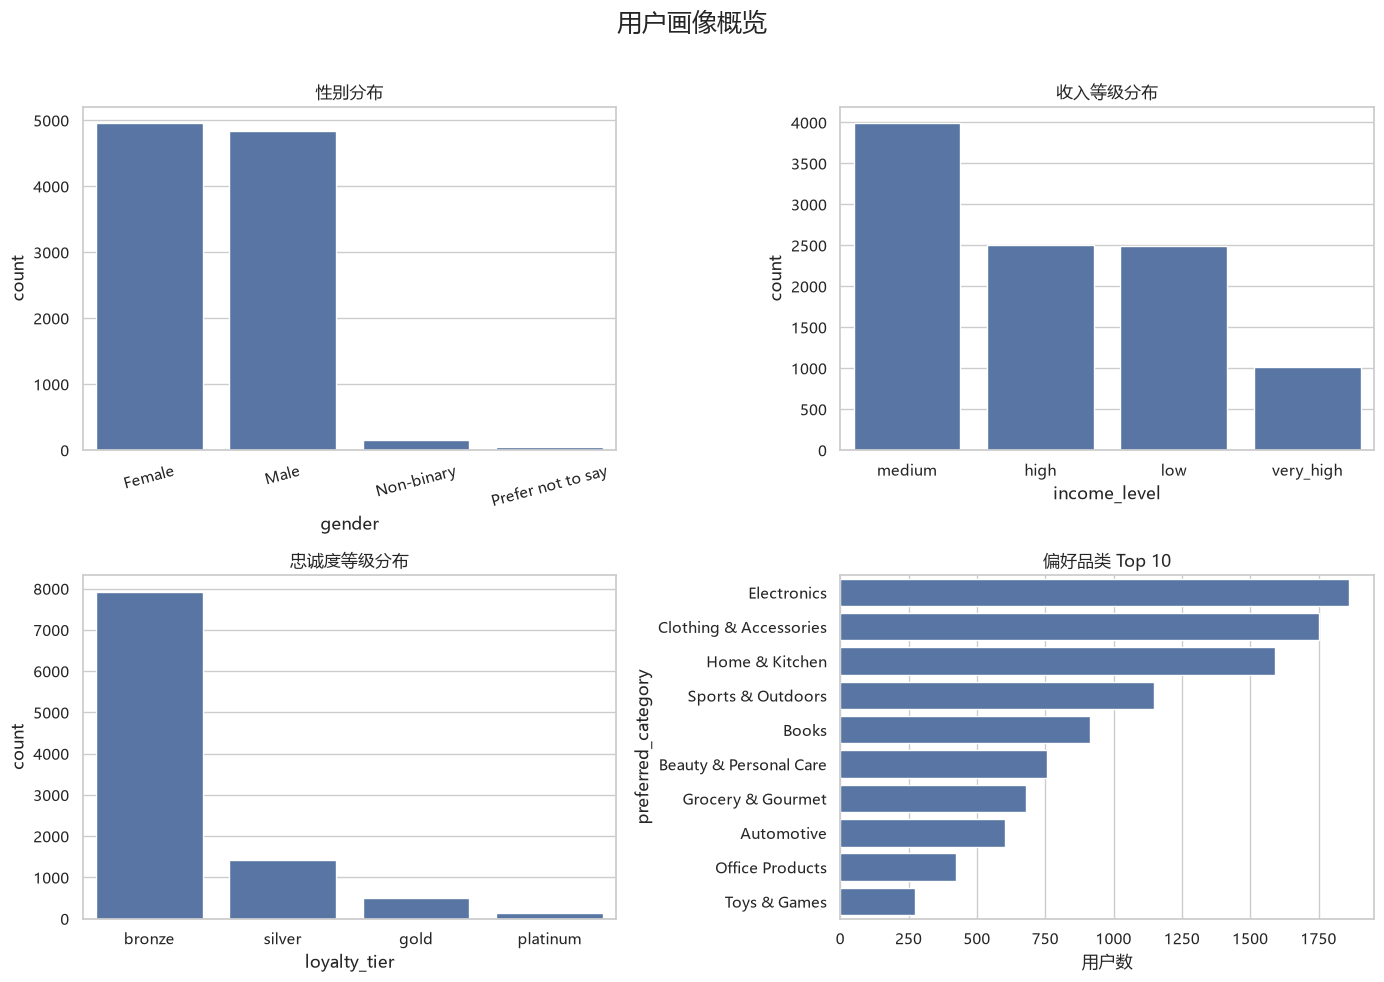

In [3]:
users = data['users']

print('用户总数:', len(users))
display(users['gender'].value_counts().to_frame('用户数'))
display(users['income_level'].value_counts().to_frame('用户数'))
display(users['loyalty_tier'].value_counts().to_frame('用户数'))
display(users['preferred_category'].value_counts().head(10).to_frame('用户数'))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

gender_order = users['gender'].value_counts().index
sns.countplot(data=users, x='gender', order=gender_order, ax=axes[0, 0])
axes[0, 0].set_title('性别分布')
axes[0, 0].tick_params(axis='x', rotation=15)

income_order = users['income_level'].value_counts().index
sns.countplot(data=users, x='income_level', order=income_order, ax=axes[0, 1])
axes[0, 1].set_title('收入等级分布')

loyalty_order = ['bronze', 'silver', 'gold', 'platinum']
sns.countplot(data=users, x='loyalty_tier', order=loyalty_order, ax=axes[1, 0])
axes[1, 0].set_title('忠诚度等级分布')

top_categories = users['preferred_category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[1, 1])
axes[1, 1].set_title('偏好品类 Top 10')
axes[1, 1].set_xlabel('用户数')

fig.suptitle('用户画像概览', fontsize=18)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## 3. 用户行为概览

活跃用户数: 6944
会话数: 19315
交互记录数: 100000
平均每个会话产生交互次数: 5.18


,交互次数
interaction_type,
view,50463
click,19983
add_to_cart,11860
add_to_wishlist,10168
remove_from_wishlist,4795
remove_from_cart,2731


,会话数
device_type,
mobile,11069
desktop,6236
tablet,2010


,转化率 %
referrer_source,
display_ad,8.05
paid_search,8.02
email,7.63
referral,7.44
direct,7.40
organic_search,7.38
social_media,7.24


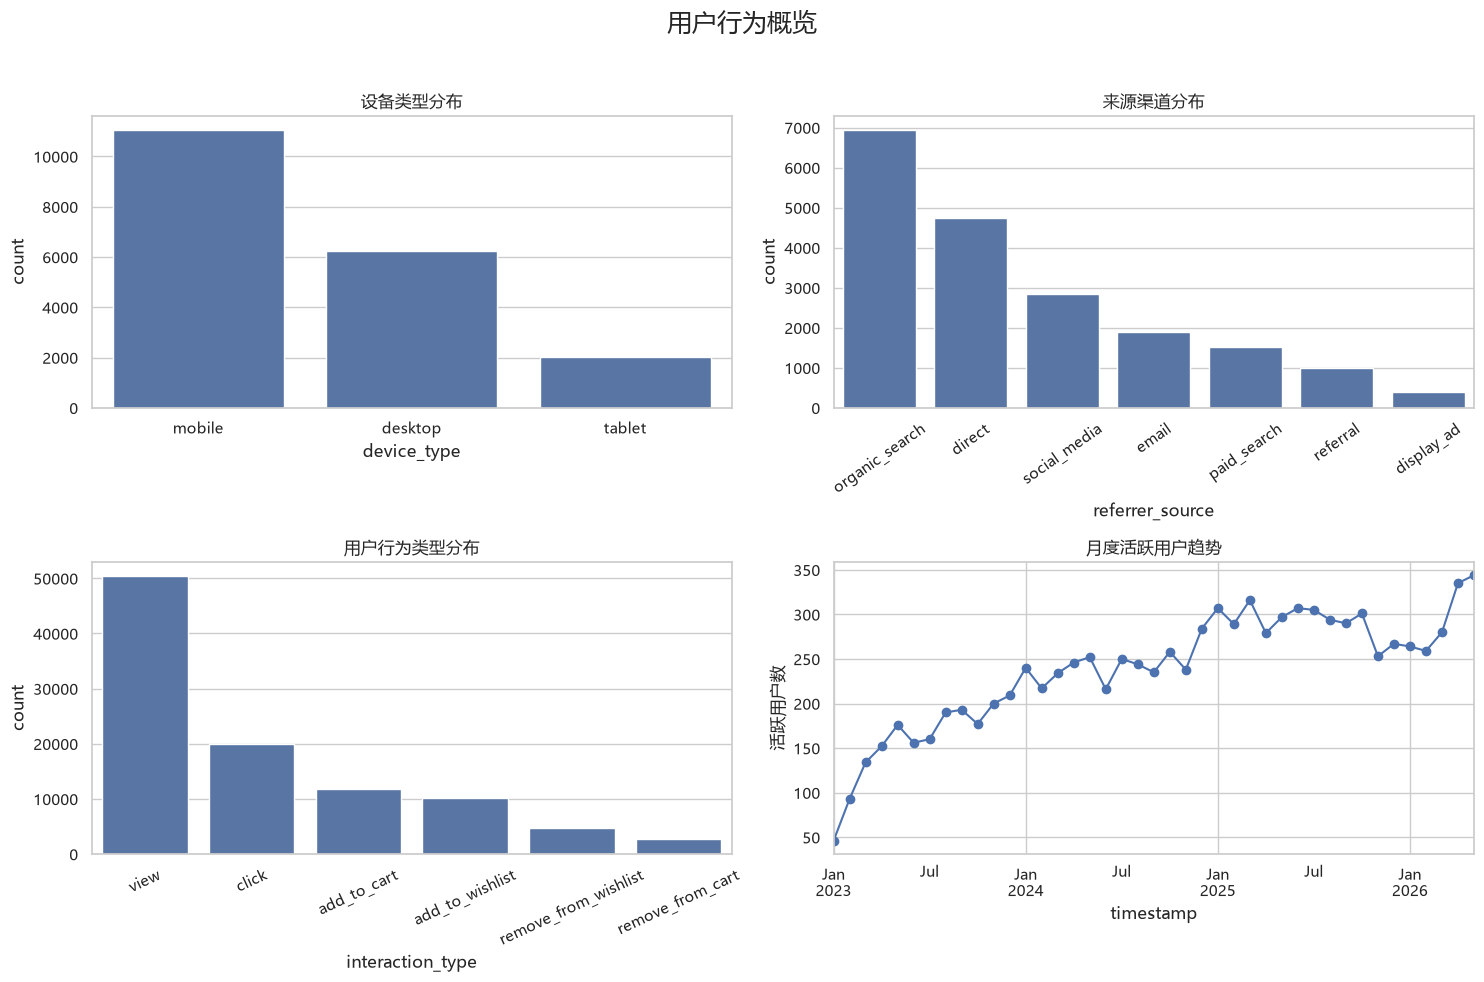

In [4]:
sessions = data['sessions']
interactions = data['interactions']

active_users = sessions['user_id'].nunique()
total_sessions = len(sessions)
total_interactions = len(interactions)
interactions_per_session = total_interactions / total_sessions

print('活跃用户数:', active_users)
print('会话数:', total_sessions)
print('交互记录数:', total_interactions)
print('平均每个会话产生交互次数:', round(interactions_per_session, 2))

display(interactions['interaction_type'].value_counts().to_frame('交互次数'))
display(sessions['device_type'].value_counts().to_frame('会话数'))
display(
    sessions.groupby('referrer_source')['is_converted']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .to_frame('转化率 %')
)

monthly_active_users = (
    interactions.set_index('timestamp')
    .resample('ME')['user_id']
    .nunique()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

device_order = sessions['device_type'].value_counts().index
sns.countplot(data=sessions, x='device_type', order=device_order, ax=axes[0, 0])
axes[0, 0].set_title('设备类型分布')

source_order = sessions['referrer_source'].value_counts().index
sns.countplot(data=sessions, x='referrer_source', order=source_order, ax=axes[0, 1])
axes[0, 1].set_title('来源渠道分布')
axes[0, 1].tick_params(axis='x', rotation=35)

interaction_order = interactions['interaction_type'].value_counts().index
sns.countplot(data=interactions, x='interaction_type', order=interaction_order, ax=axes[1, 0])
axes[1, 0].set_title('用户行为类型分布')
axes[1, 0].tick_params(axis='x', rotation=25)

monthly_active_users.plot(ax=axes[1, 1], marker='o')
axes[1, 1].set_title('月度活跃用户趋势')
axes[1, 1].set_ylabel('活跃用户数')

fig.suptitle('用户行为概览', fontsize=18)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 4. 转化漏斗分析

口径说明：
- 每个步骤按会话数去重统计。
- overall_rate：当前步骤会话数 / 浏览步骤会话数。
- step_rate：当前步骤会话数 / 上一步会话数。

,step,sessions,users,overall_rate,step_rate
0,view,19315,6944,100.00,NaN
1,click,11535,5639,59.72,59.72
2,add_to_cart,8371,4811,43.34,72.57
3,purchase,1440,1287,7.46,17.20


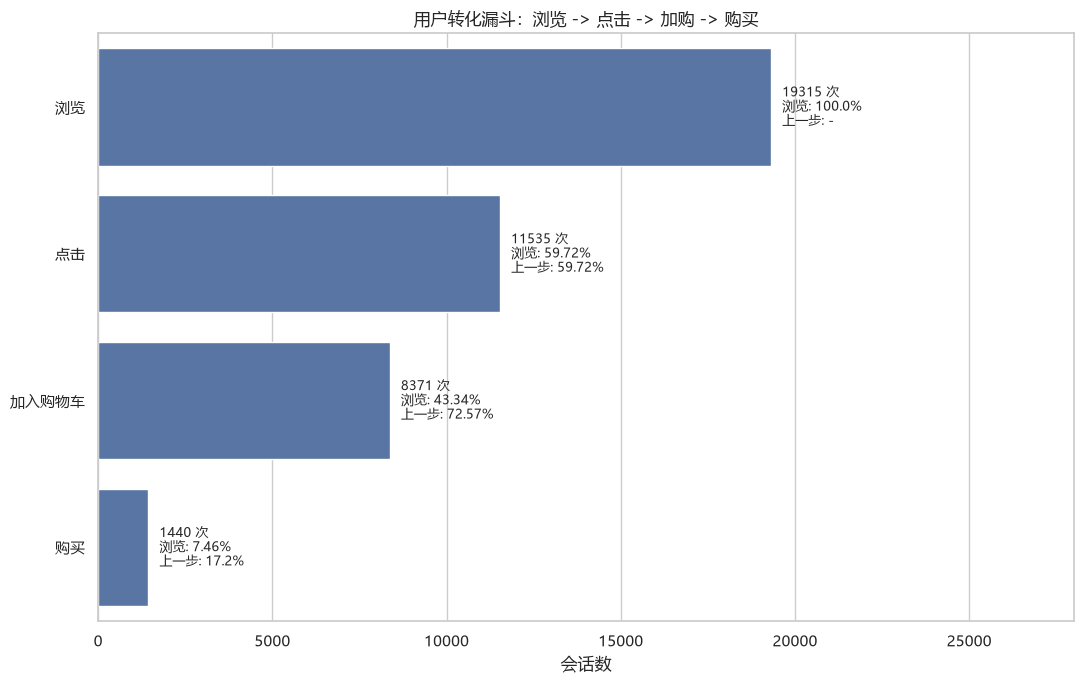

In [5]:
purchases = data['purchases']

# 漏斗步骤固定为：浏览、点击、加购、购买。
steps = ['view', 'click', 'add_to_cart', 'purchase']
session_counts = []
user_counts = []

# 前三个步骤从 interactions 中统计，购买步骤从 purchases 中统计。
for step in steps[:-1]:
    step_data = interactions[interactions['interaction_type'] == step]
    session_counts.append(step_data['session_id'].nunique())
    user_counts.append(step_data['user_id'].nunique())

session_counts.append(purchases['session_id'].nunique())
user_counts.append(purchases['user_id'].nunique())

funnel = pd.DataFrame({
    'step': steps,
    'sessions': session_counts,
    'users': user_counts,
})
# 相对浏览转化率。
first_step_sessions = funnel.loc[0, 'sessions']
funnel['overall_rate'] = (funnel['sessions'] / first_step_sessions * 100).round(2)
# 相对上一步转化率。
previous_sessions = funnel['sessions'].shift(1)
funnel['step_rate'] = (funnel['sessions'] / previous_sessions * 100).round(2)

display(funnel)

# 把英文步骤改成中文，方便看图。
funnel_data = funnel.copy()
funnel_data['step'] = funnel_data['step'].replace({
    'view': '浏览',
    'click': '点击',
    'add_to_cart': '加入购物车',
    'purchase': '购买',
})

# 准备柱子标签，同时展示会话数和两种转化率。
label_texts = []
for _, row in funnel_data.iterrows():
    if pd.isna(row['step_rate']):
        step_text = '上一步: -'
    else:
        step_text = f"上一步: {row['step_rate']}%"

    label_texts.append(
        f"{int(row['sessions'])} 次\n"
        f"浏览: {row['overall_rate']}%\n"
        f"{step_text}"
    )

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=funnel_data, x='sessions', y='step', color='#4C72B0', ax=ax)
ax.set_title('用户转化漏斗：浏览 -> 点击 -> 加购 -> 购买')
ax.set_xlabel('会话数')
ax.set_ylabel('')
ax.set_xlim(0, funnel_data['sessions'].max() * 1.45)
ax.bar_label(ax.containers[0], labels=label_texts, padding=8, fontsize=9)
fig.tight_layout()
plt.show()

## 5. 用户留存分析

口径说明：
- cohort：按用户注册月份分组。
- 分子：该 cohort 中，在对应月份至少产生一次会话的用户数。
- 分母：该 cohort 的注册用户总数。
- 首月不是 100%，因为部分注册用户没有出现在会话数据中。

注册用户总数: 10000
有会话记录的注册用户数: 6944


month_index,0,1,2,3,4,5
cohort_month,,,,,,
2025-06,53.5,35.4,6.7,1.0,0.0,0.0
2025-07,54.9,35.2,6.5,2.0,0.0,0.0
2025-08,58.3,36.0,7.2,1.1,0.0,0.0
2025-09,55.6,41.1,8.3,1.3,0.0,0.0
2025-10,52.6,31.4,6.6,0.3,0.0,0.0
2025-11,49.5,33.3,6.6,2.9,0.0,0.0
2025-12,54.1,32.9,7.1,1.1,0.4,0.0
2026-01,52.6,34.6,7.3,1.4,0.3,0.0
2026-02,50.4,37.7,8.8,0.0,0.0,0.0


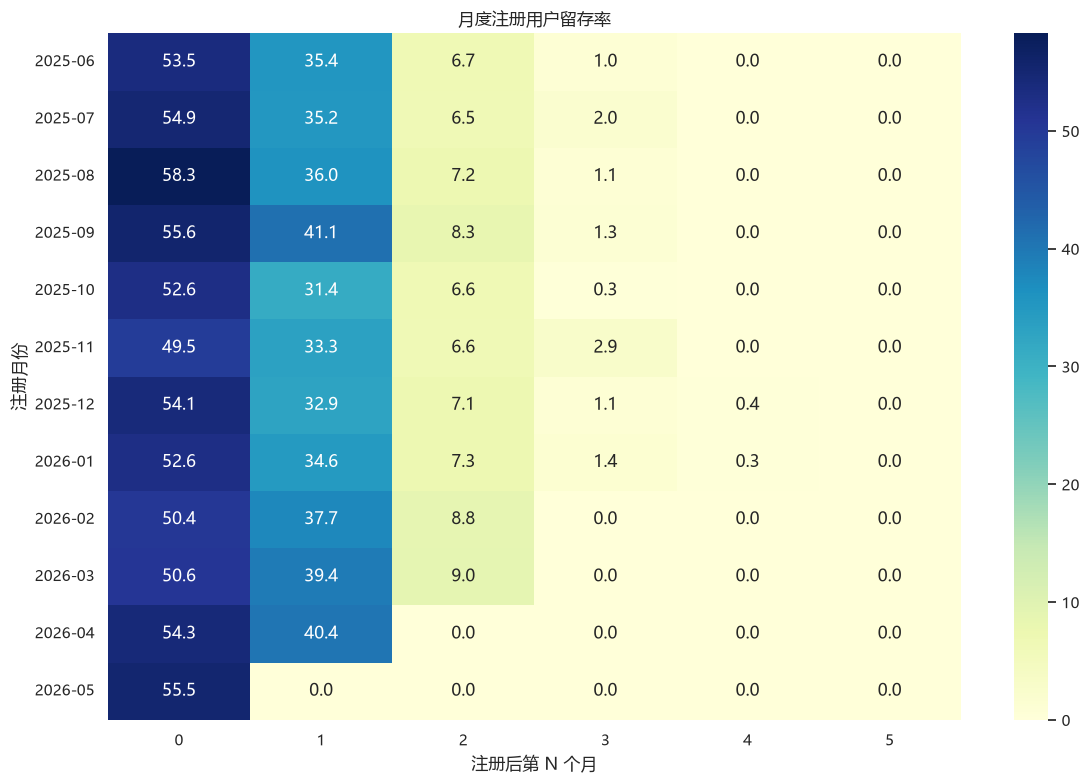

In [6]:
# cohort：注册月份。
# 分子：该 cohort 中在对应月份有会话的用户数。
# 分母：该 cohort 的注册用户总数。
signup_info = users[['user_id', 'signup_date']].dropna(subset=['signup_date'])
active_users = sessions.merge(signup_info, on='user_id', how='inner')

print('注册用户总数:', len(signup_info))
print('有会话记录的注册用户数:', active_users['user_id'].nunique())

# cohort_month：注册月份。
# activity_month：发生会话的月份。
active_users['cohort_month'] = active_users['signup_date'].dt.to_period('M')
active_users['activity_month'] = active_users['start_time'].dt.to_period('M')
# month_index：活跃月份距离注册月份几个月。
active_users['month_index'] = (
    (
        active_users['activity_month'].dt.year
        - active_users['cohort_month'].dt.year
    ) * 12
    + (
        active_users['activity_month'].dt.month
        - active_users['cohort_month'].dt.month
    )
)

# 每个 cohort 在后续各月活跃的唯一用户数。
cohort_counts = (
    active_users.groupby(['cohort_month', 'month_index'])['user_id']
    .nunique()
    .unstack(fill_value=0)
)
cohort_counts = cohort_counts.loc[cohort_counts.index[-12:], 0:6]

# 每个 cohort 的注册用户总数。
cohort_sizes = signup_info['signup_date'].dt.to_period('M').value_counts()
cohort_sizes = cohort_sizes.reindex(cohort_counts.index).fillna(0)

# 留存率 = 活跃用户数 / 注册用户总数。
retention_rate = cohort_counts.div(cohort_sizes, axis=0) * 100
display(retention_rate.round(1))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(retention_rate, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title('月度注册用户留存率')
ax.set_xlabel('注册后第 N 个月')
ax.set_ylabel('注册月份')
fig.tight_layout()
plt.show()

## 6. 商品与品类分析

,revenue,orders,buyers,quantity
category,,,,
Electronics,40316.42,236,224,269
Sports & Outdoors,21000.52,201,187,305
Home & Kitchen,17712.88,212,202,309
Clothing & Accessories,15202.68,264,243,392
Automotive,10656.95,121,118,161
Books,6864.55,131,129,252
Office Products,5638.30,86,84,127
Beauty & Personal Care,5571.39,139,131,197
Toys & Games,4292.40,90,88,118


,product_name,category,views,purchases,conversion_rate
34,Apple Accessorie Stand,Electronics,3329,84,2.52
205,The Data Structures: A Comprehensive Guide,Books,1954,43,2.20
849,Instant Pot Microfiber Kitchenware,Home & Kitchen,1629,41,2.52
996,Wilson Book19 Fitness Equipment,Sports & Outdoors,1599,41,2.56
237,Tommy Hilfiger Womenswear Dress,Clothing & Accessories,1461,37,2.53
67,Post-it Premium Stationery Set,Office Products,1330,34,2.56
690,Michelin Heavy-Duty Car Accessorie,Automotive,1309,29,2.22
231,Wilson Fitness Equipment Pro,Sports & Outdoors,1264,55,4.35
131,Neutrogena Bath & Body Lotion,Beauty & Personal Care,1073,37,3.45
176,Cuisinart Smart Appliance,Home & Kitchen,1061,41,3.86


,评论数
rating,
1,64
2,108
3,150
4,286
5,645


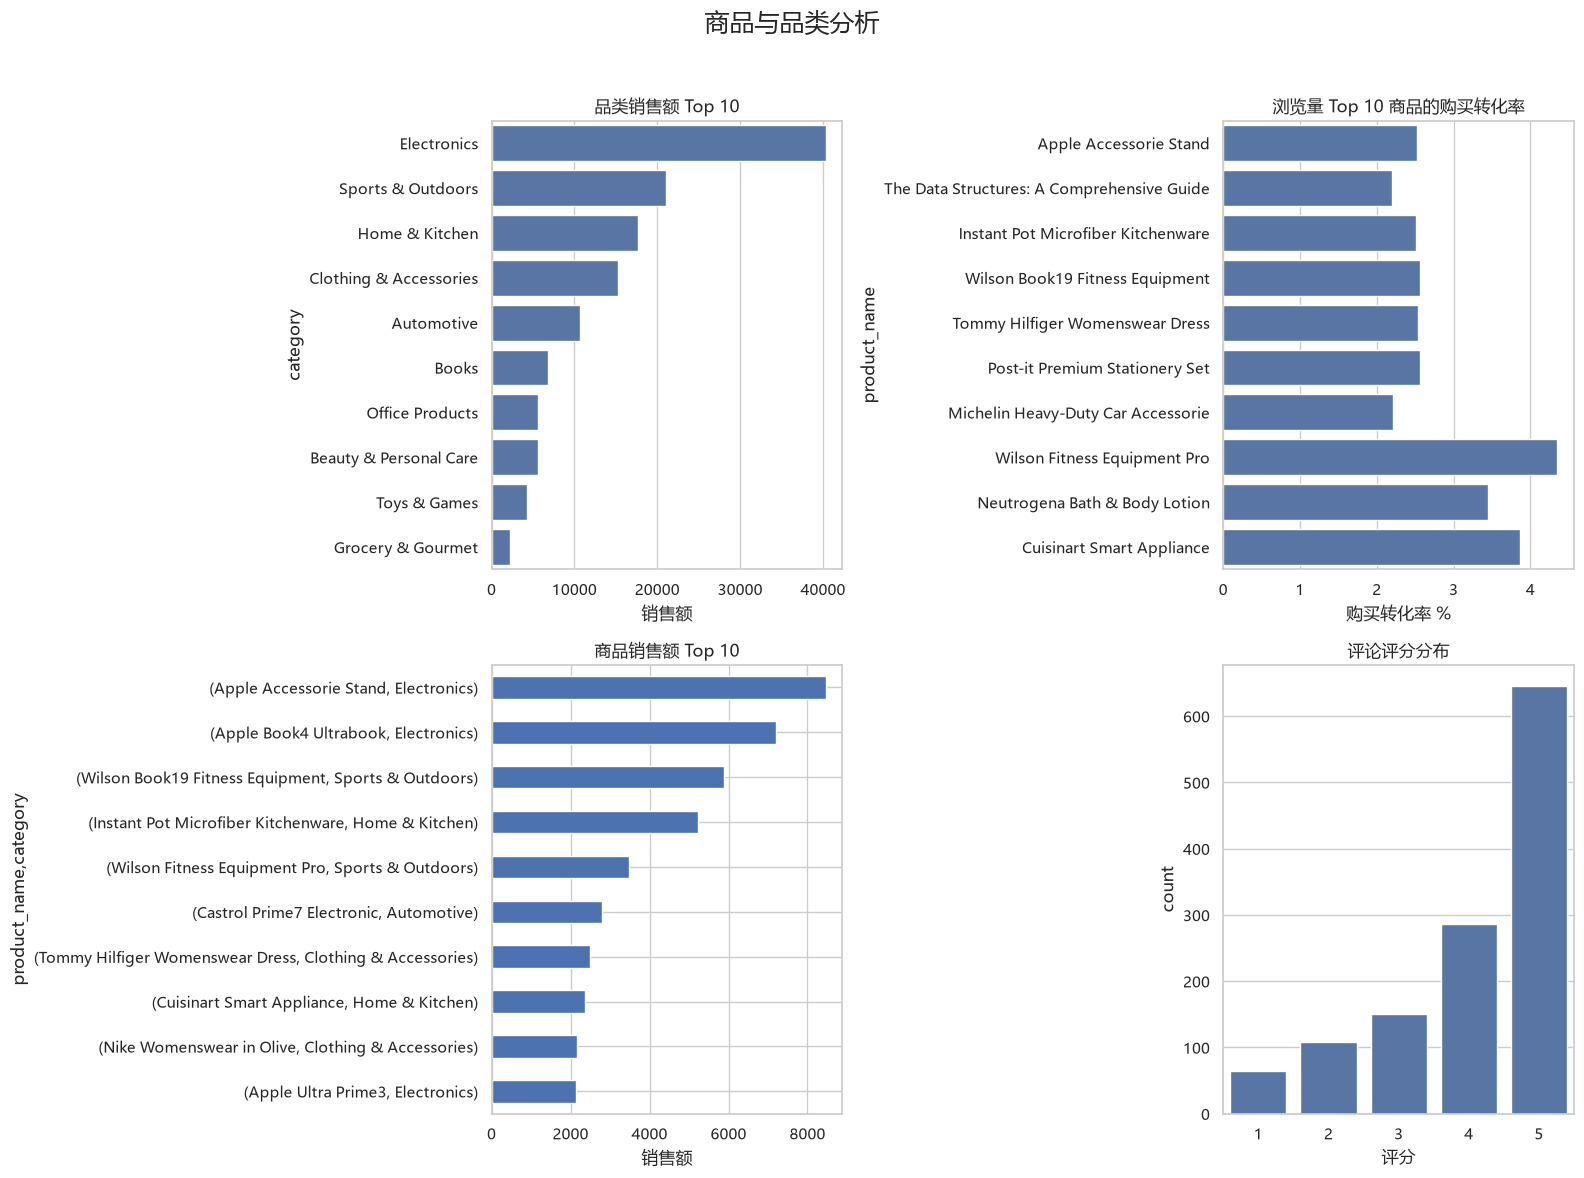

In [7]:
products = data['products']
reviews = data['reviews']

purchase_products = purchases.merge(
    products[['product_id', 'product_name', 'category', 'subcategory']],
    on='product_id',
    how='left',
)

category_summary = (
    purchase_products.groupby('category')
    .agg(
        revenue=('total_amount', 'sum'),
        orders=('order_id', 'nunique'),
        buyers=('user_id', 'nunique'),
        quantity=('quantity', 'sum'),
    )
    .sort_values('revenue', ascending=False)
)

display(category_summary.head(10).round(2))

views = (
    interactions[interactions['interaction_type'] == 'view']
    .groupby('product_id')
    .size()
    .rename('views')
)
purchase_counts = (
    purchases.groupby('product_id')
    .size()
    .rename('purchases')
)

product_conversion = (
    products[['product_id', 'product_name', 'category']]
    .merge(views, on='product_id', how='left')
    .merge(purchase_counts, on='product_id', how='left')
)
product_conversion['views'] = product_conversion['views'].fillna(0).astype(int)
product_conversion['purchases'] = product_conversion['purchases'].fillna(0).astype(int)
product_conversion['conversion_rate'] = (
    product_conversion['purchases'] / product_conversion['views'] * 100
)
product_conversion.loc[product_conversion['views'] == 0, 'conversion_rate'] = 0

top_conversion = product_conversion.nlargest(10, 'views')[
    ['product_name', 'category', 'views', 'purchases', 'conversion_rate']
]
display(top_conversion.round(2))

product_revenue = (
    purchase_products.groupby(['product_name', 'category'])['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

rating_distribution = reviews['rating'].value_counts().sort_index()
display(rating_distribution.to_frame('评论数'))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_categories = category_summary.head(10)
sns.barplot(x=top_categories['revenue'].values, y=top_categories.index, ax=axes[0, 0])
axes[0, 0].set_title('品类销售额 Top 10')
axes[0, 0].set_xlabel('销售额')

sns.barplot(data=top_conversion, x='conversion_rate', y='product_name', ax=axes[0, 1])
axes[0, 1].set_title('浏览量 Top 10 商品的购买转化率')
axes[0, 1].set_xlabel('购买转化率 %')

product_revenue.sort_values().plot.barh(ax=axes[1, 0])
axes[1, 0].set_title('商品销售额 Top 10')
axes[1, 0].set_xlabel('销售额')

sns.countplot(data=reviews, x='rating', ax=axes[1, 1])
axes[1, 1].set_title('评论评分分布')
axes[1, 1].set_xlabel('评分')

fig.suptitle('商品与品类分析', fontsize=18)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 业务结论与建议

### 1. 用户结构
用户以女性、中等收入、青铜会员为主，偏好品类集中在 Electronics、Clothing & Accessories、Home & Kitchen。
说明用户基本盘偏大众消费，忠诚度体系尚未形成有效分层。

建议：
- 针对青铜会员设计首购礼、满减和成长任务，推动向 silver/gold 升级。
- 围绕三大偏好品类做首页推荐和组合促销，提高用户复购。

### 2. 行为与渠道
移动端会话占比最高，约 57%，是主要体验入口。
display_ad 和 paid_search 的转化率最高，均约 8%，是当前效率较好的获客渠道。
organic_search 流量最大但转化率约 7.4%，仍有优化空间。

建议：
- 优先优化移动端浏览、搜索和结算流程。
- 保持 paid_search 和 display_ad 的预算，同时提升 organic_search 的落地页相关性。

### 3. 转化漏斗
浏览 -> 点击 -> 加购转化相对平稳，但加购到购买的转化率只有约 17.2%，是最大流失点。
最终整体会话购买转化率约 7.5%。

建议：
- 重点治理加购后流失，包括结算步骤、运费、支付方式、库存和价格透明度。
- 对加购未购买用户做购物车召回、优惠券和限时提醒。

### 4. 用户留存
用户注册首月活跃率约 50%-58%，次月约 31%-41%，但第 2 个月后快速下降至 10% 以下。
说明短期留存尚可，长期留存明显不足。

建议：
- 在注册后 7 天、30 天设置关键动作引导和会员任务。
- 建立邮件、短信或站内消息的召回机制，延长用户生命周期。
- 增加复购权益、订阅服务和积分体系，提升长期留存。

### 5. 商品与品类
Electronics 销售额最高，Sports & Outdoors、Home & Kitchen 次之。
Clothing & Accessories 订单量最高，但客单价和销售额不如 Electronics。
商品浏览到购买的转化率普遍在 2%-4% 左右，热门浏览商品仍有明显提升空间。
评论评分以 5 分和 4 分为主，商品口碑整体较好。

建议：
- 把 Electronics 作为利润和销售额核心类目，强化新品和高客单价商品运营。
- 对 Clothing & Accessories 提升连带率和客单价，例如搭配推荐、满件折扣。
- 对高浏览量低转化商品优化详情页、价格、评论和库存，提升商品页转化效率。
- 利用高分评价和用户评论内容做信任背书，降低购买决策门槛。
